In [420]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

## Goal
The goal of this lab is to investigate electromagnetic induction in a transformer. Specifically, we aim to determine how the induced voltage in the secondary coil depends on the number of turns it contains. Using this relationship, we will calculate the number of turns required to design a transformer that produces a 1.0 V peak-to-peak signal.



##  Procedure for the Lab
* Construct a transformer by placing an air-core solenoid as the primary coil.
* Connect CH1 of the oscilloscope to the primary coil to observe the input signal.
* Build a secondary coil by winding 10 number of turns around an iron core.
* Connect the secondary coil to CH2 of the oscilloscope.
* Insert the secondary coil inside the primary coil.
* Record the peak to peak voltage from the secondary coil.
* Repeat measurements with decreasing number of turns on the secondary coil from 10 to 1.
* Plot the induced voltage vs. number of turns and apply a linear fit.
* Use the linear model to predict the number of turns required to get a 1.0 V output.


#### Importing the data from our measurments

In [424]:
data = pd.read_excel("data/data1.xlsx")
data.head()

,Turns,Channel 1 (m_Volt),Channel 2 (m_Volt)
0,10,21,424
1,9,21,384
2,8,21,352
3,7,21,308
4,6,21,260


## We started with 10 turns and then started to decrease the number of turns by 1 as we repeated the process

###  Voltage Measurement Uncertainty (LCR Meter)

The total uncertainty in a voltage measurement from an LCR meter is given by:

$$
\Delta V = 0.5 \times V_{\text{measured}} + 1
$$




In [428]:
volt_uncertainity = lambda x: x * 0.05 + 1


$$
\text{Sine Wave Frequency} = 1500\ \text{Hz}
$$


$$
\text{uncertainity of turns} = 0.5
$$


###  Dominant Source of Uncertainty

The dominant source of uncertainty in this experiment arises from the difficulty in achieving an exact, discrete number of turns on the secondary coil. When winding the wire around the rod, there are almost always partial turns either at the start or end of the coil. These fractional turns introduce ambiguity in the total number of loops that contribute to the magnetic flux linkage.

Since the induced voltage in the secondary coil is directly proportional to the number of effective turns, even small deviations from whole turns can lead to measurable differences in the observed voltage. This ultimately affects the precision of the transformer’s output and adds uncertainty to the linear relationship between voltage and number of turns.


In [433]:
data["d_v"] = data["Channel 2 (m_Volt)"].apply(lambda x: volt_uncertainity(x))
data["d_n"] = 0.5
data

,Turns,Channel 1 (m_Volt),Channel 2 (m_Volt),d_v,d_n
0,10,21,424,22.2,0.5
1,9,21,384,20.2,0.5
2,8,21,352,18.6,0.5
3,7,21,308,16.4,0.5
4,6,21,260,14.0,0.5
5,5,21,210,11.5,0.5
6,4,21,174,9.7,0.5
7,3,21,132,7.6,0.5
8,2,21,98,5.9,0.5
9,1,21,50,3.5,0.5


#### Visualizing the plot to see if the kind of relationship between the number of turns in the secondary coil and the voltage measured


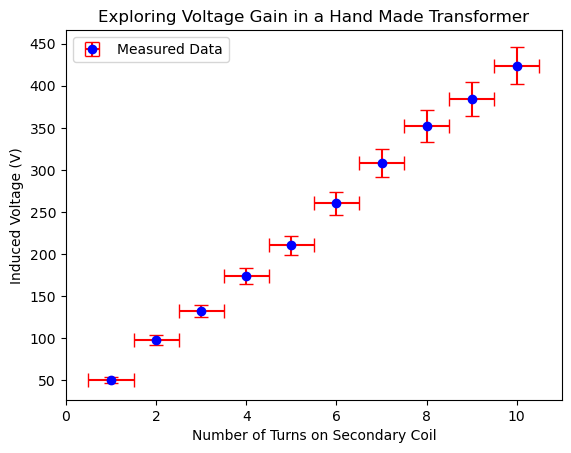

In [435]:
y = data["Channel 2 (m_Volt)"]
x = data["Turns "]
y_err = data["d_v"]
x_err = data["d_n"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Number of Turns on Secondary Coil")
plt.ylabel(r"Induced Voltage (V)")
plt.title("Exploring Voltage Gain in a Hand Made Transformer")
plt.legend()
plt.show()


#### The relationship looks linear, lets have a regression fit to get an estimate for the slope

In [437]:
def linear_model(x, A, B):
    return  A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
print(f"{slope:.2e}, {intercept:.2e}")
print(errors)

4.18e+01, 9.04e+00
[[ 1.4115909  -3.42726607]
 [-3.42726607 14.49203742]]


$$
\text{Estimated Slope} = 42 \pm 14
\text{Estimated Intercept} = 9 \pm 1
$$


$$
\text{Estimated Slope} = 42 \pm 14 \space \text{mv}
$$
$$
\text{Estimated Intercept} = 9 \pm 1 \space \text{mv}
$$


###  Comparison to Accepted Value from Primary Coil

The primary solenoid was driven with a 21 V peak-to-peak signal and had 260 turns. This gives an expected voltage-per-turn of:

$$
\text{Accepted Slope} = \frac{21\ \text{V}}{260\ \text{turns}} \approx 0.0808\ \text{V/turn} = 80.8\ \text{mV/turn}
$$

Our experimental slope was:

$$
\text{Measured Slope} = d  \pm 14\ \text{mV/turn}
$$
Our measured slope is about half the expected value, which can be explained by several practical limitations. First, it’s difficult to wind the secondary coil with perfect precision becaue the number of turns may not be exact, and small gaps between loops reduce how much magnetic flux each turn captures. These spacing inconsistencies weaken the coupling between the coils. Combined with flux leakage from the air-core solenoid, these factors likely caused the lower-than-expected voltage. Still, the results follow the expected trend of linearity, supporting Faraday’s Law.


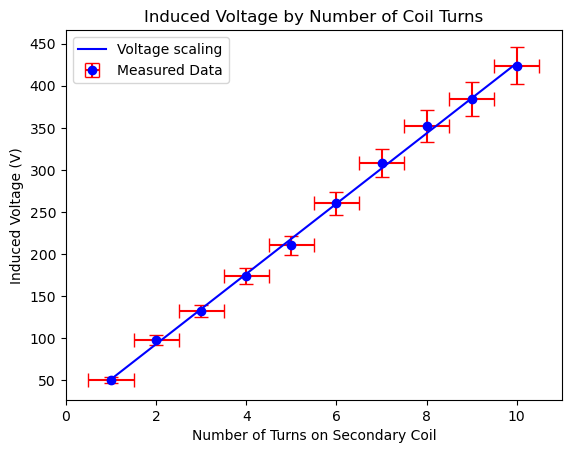

In [441]:
# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel("Number of Turns on Secondary Coil")
plt.ylabel("Induced Voltage (V)")
plt.title("Induced Voltage by Number of Coil Turns")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Voltage scaling", color='blue')

plt.legend(); 
plt.show()

To determine how many turns are needed on the secondary coil to produce a desired voltage output (e.g., 1.0 V), we rearrange the linear regression equation:

$$
V_s = m \cdot N + b
$$

Where:
- \( V_s \) is the desired secondary voltage,
- \( m \) is the slope from the linear regression (voltage per turn},
- \( b \) is the y-intercept,
- \( N \) is the number of turns.

Solving for \( N \):

$$
N = \frac{V_s - b}{m}
$$

We use this expression to estimate how many turns are needed to achieve a specific voltage output based on the experimental relationship we observed.


### 🧮 Uncertainty Propagation Formula

Given:

$$
N = \frac{V_s - b}{m}
$$

We propagate the uncertainty using partial derivatives:

$$
(\delta N)^2 = \left( \frac{\partial N}{\partial m} \cdot \delta m \right)^2 + \left( \frac{\partial N}{\partial b} \cdot \delta b \right)^2
$$

Compute derivatives:

$$
\frac{\partial N}{\partial m} = -\frac{V_s - b}{m^2} = -\frac{N}{m}
$$

$$
\frac{\partial N}{\partial b} = -\frac{1}{m}
$$

So:

$$
\delta N = \sqrt{ \left( \frac{N}{m} \cdot \delta m \right)^2 + \left( \frac{1}{m} \cdot \delta b \right)^2 }
$$


In [445]:
N = lambda v, b, m: (v - b) / m
N_error = lambda n, m, d_m, d_b: np.sqrt( ((n/m) * d_m)**2 + (d_b/m)**2 )

In [446]:
## Calculating the turns and its erorr
turns = N(1, intercept, slope)
d_slope, d_intercept = errors[1, 1], errors[0, ]
d_turns = N_error(turns, slope, d_slope, d_intercept)

turns, d_turns

(-0.19246095501564195, array([0.07479438, 0.10572544]))


$$
\text{Number of Turns Required} = 0.2 \pm{0.07} \space\space \text{Turns}
$$



### Physics Connection

Faraday’s Law tells us that the voltage induced in a coil is related to the number of turns — more turns mean more magnetic flux is captured, and that means more voltage is produced. According to Faraday's law, this relationship should be directly proportional.

OUr result was about 0.2 turns — which obviously isn’t physically realistic. You can’t wind a fraction of a turn neatly onto a coil, and this is where real-world limitations arrive.


Despite these factors, the experiment still supports Faraday’s Law, showing a clear linear trend between coil turns and voltage. 


## Apparatus diagram
##### (I forgot my phone in the lab and its still there)

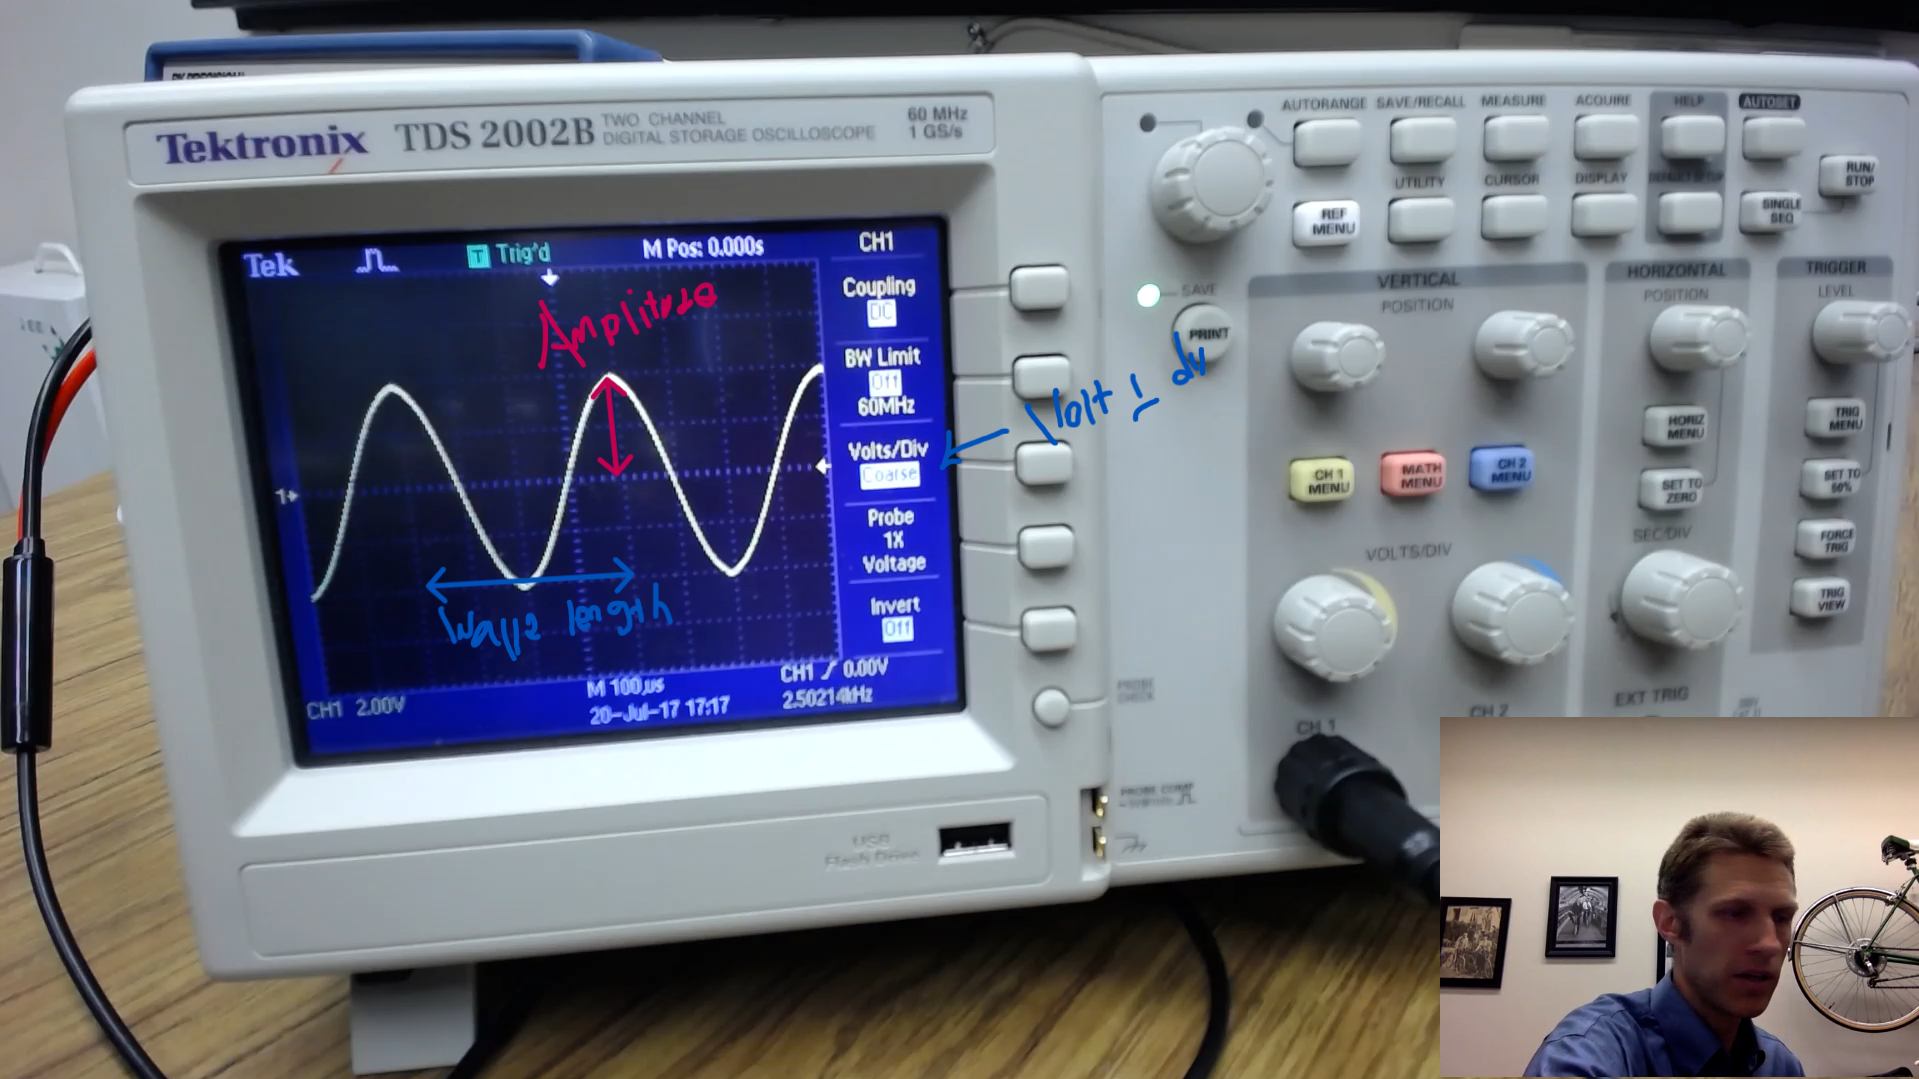

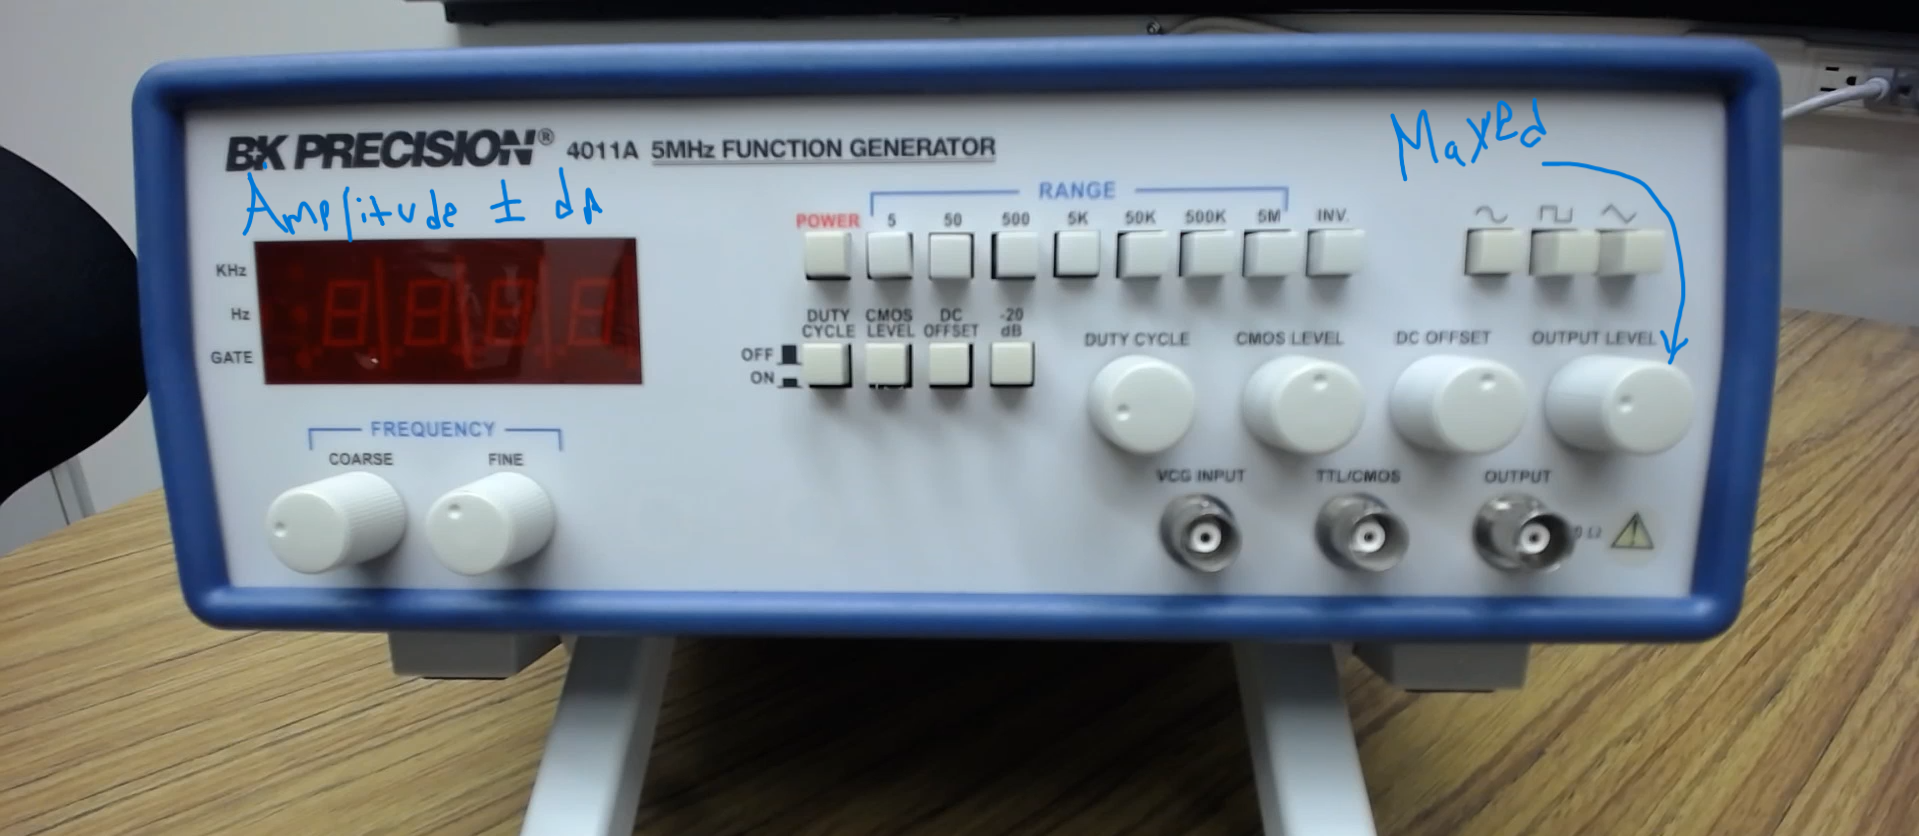

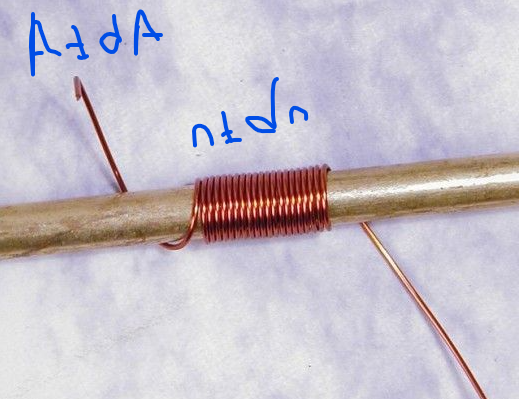